## Dataset Description
The dataset `insurance.csv` contains 1,338 records of people covered by health insurance.

| Variable | Description |
|---|---|
| `age` | Age of the person |
| `sex` | Gender (`female` / `male`) |
| `bmi` | Body mass index (kg/m²) |
| `children` | Number of children/dependents covered by the insurance |
| `smoker` | Whether the person smokes (`yes` / `no`) |
| `region` | Residential area in the US (northeast, northwest, southeast, southwest) |
| `charges` | Personal medical costs billed by the insurance (USD). **This is the target.** |

In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('insurance.csv')
data.head()
data.shape
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There are no missing values, so no data cleaning is needed.

## Data Visualization

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

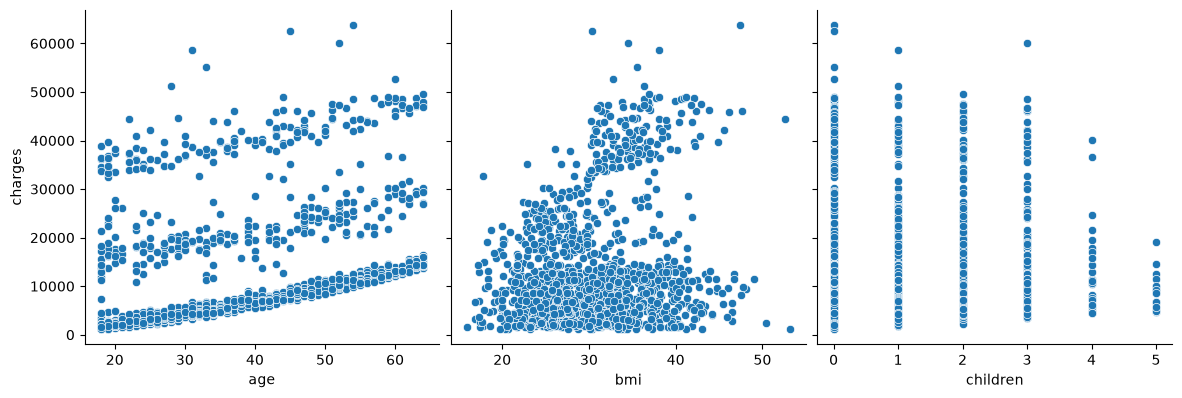

In [4]:
sns.pairplot(data, x_vars=['age', 'bmi', 'children'], y_vars='charges', height=4, aspect=1, kind='scatter')
plt.show()

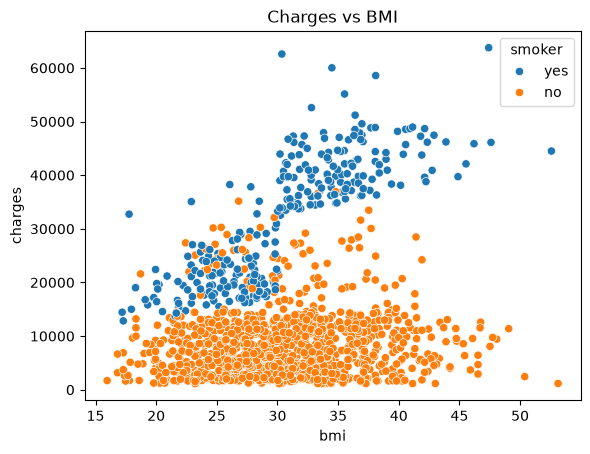

In [5]:
sns.scatterplot(data=data, x='bmi', y='charges', hue='smoker')
plt.title('Charges vs BMI')
plt.show()

The scatter plots show that `age` has a clear positive relationship with `charges`. In the BMI plot, smokers (especially those with BMI above 30) have much higher charges than non-smokers.

## Task 1: Identify Features and Target
- **Features (independent variables):** `age`, `sex`, `bmi`, `children`, `smoker`, `region`
- **Target (dependent variable):** `charges`

`sex`, `smoker` and `region` are text (categorical), so they must be converted to numbers first. Here `pd.get_dummies` is used (one-hot encoding).

In [6]:
data_encoded = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)
data_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


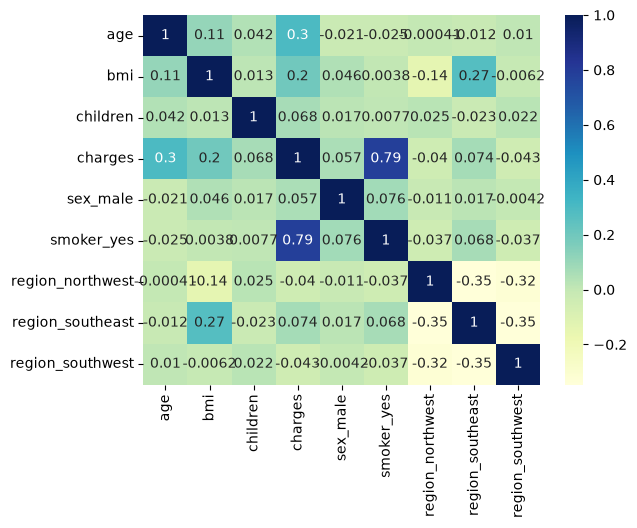

In [7]:
sns.heatmap(data_encoded.corr(), cmap="YlGnBu", annot=True)
plt.show()

The heatmap shows that `smoker_yes` has the strongest correlation with `charges`, followed by `age` and `bmi`. `sex_male` and the region columns have almost no correlation.

In [8]:
X = data_encoded.drop(columns='charges')
y = data_encoded['charges']

## Task 2: Split the Data into Training and Testing Sets
A 70% / 30% split is used. It is stratified on `smoker` (as in the Stratified Split lab), so training and test sets keep the same proportion of smokers.

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100, stratify=data['smoker'])

In [10]:
print(f'Training data count: {X_train.shape[0]}')
print(f'Test data count: {X_test.shape[0]}')
print(f'Smoker proportion in training data: {X_train["smoker_yes"].mean():.3f}')
print(f'Smoker proportion in test data: {X_test["smoker_yes"].mean():.3f}')

Training data count: 936
Test data count: 402
Smoker proportion in training data: 0.205
Smoker proportion in test data: 0.204


## Task 3: Feature Scaling
The features have very different ranges (e.g. `age` up to 64, `bmi` around 30, dummy columns 0/1). They are standardized with `StandardScaler`. The scaler is **fitted on the training data only** and then applied to the test data. Scaling is especially important for SVR.

In [11]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train_sc = sc_X.fit_transform(X_train)
X_test_sc = sc_X.transform(X_test)

## Task 4 & 5: Multiple Linear Regression (Train and Predict)

In [12]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[3605.89,2024.58, 686.63,...,-348.31,-620.34,-575.45]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.317e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[38.09,35.39,31.74,...,29.59,26.68,17.19]"


In [13]:
print("Intercept:", lr.intercept_)
print(pd.Series(lr.coef_, index=X.columns))

Intercept: 13167.099260746794
age                 3605.894622
bmi                 2024.577571
children             686.627254
sex_male             -26.063052
smoker_yes          9621.184292
region_northwest    -348.312665
region_southeast    -620.339970
region_southwest    -575.445886
dtype: float64


In [14]:
y_test_pred_lr = lr.predict(X_test_sc)

## Task 6: Evaluate Linear Regression

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

r2_lr = r2_score(y_test, y_test_pred_lr)
mse_lr = mean_squared_error(y_test, y_test_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

print("R-squared:", r2_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)

R-squared: 0.7415598295173385
MSE: 36154001.704625934
RMSE: 6012.819779822603
MAE: 4198.398027548923


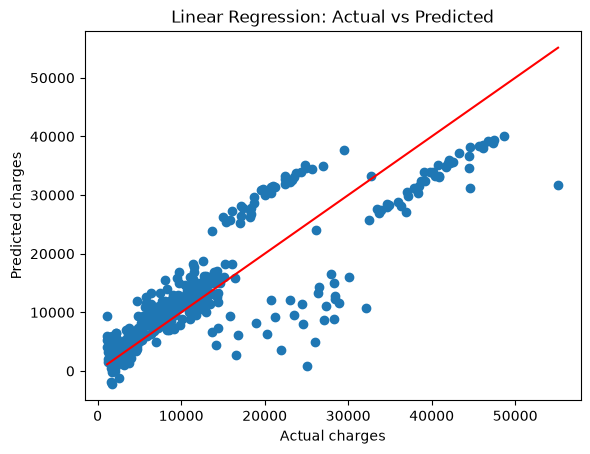

In [16]:
plt.scatter(y_test, y_test_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual charges')
plt.ylabel('Predicted charges')
plt.show()

## Task 7: Support Vector Regression (SVR)
As in the SVR lab, the target `charges` is also scaled (with its own scaler, `sc_y`) because its values are very large. Predictions are converted back with `inverse_transform` so the metrics are in dollars and can be compared with Linear Regression.

In [17]:
sc_y = StandardScaler()
y_train_sc = sc_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

### SVR with default parameters

In [18]:
from sklearn.svm import SVR
svr = SVR(kernel='rbf')
svr.fit(X_train_sc, y_train_sc)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [19]:
y_test_pred_svr = sc_y.inverse_transform(svr.predict(X_test_sc).reshape(-1, 1)).ravel()

r2_svr = r2_score(y_test, y_test_pred_svr)
mse_svr = mean_squared_error(y_test, y_test_pred_svr)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(y_test, y_test_pred_svr)

print("R-squared:", r2_svr)
print("MSE:", mse_svr)
print("RMSE:", rmse_svr)
print("MAE:", mae_svr)

R-squared: 0.8242540568992346
MSE: 24585648.25498922
RMSE: 4958.391700439692
MAE: 2696.7347638094316


### Hyperparameter tuning
**Step 1:** compare kernels and `C` (regularization strength). Each combination is scored with 5-fold cross-validation on the **training data only**, so the test data stays unseen.

In [20]:
from sklearn.model_selection import cross_val_score

results = []
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10, 100]:
        model = SVR(kernel=kernel, C=C)
        score = cross_val_score(model, X_train_sc, y_train_sc, cv=5, scoring='r2').mean()
        results.append([kernel, C, score])

tune1 = pd.DataFrame(results, columns=['kernel', 'C', 'CV R-squared'])
tune1.sort_values('CV R-squared', ascending=False)

,kernel,C,CV R-squared
5,rbf,1.0,0.843006
6,rbf,10.0,0.829578
10,poly,10.0,0.827992
11,poly,100.0,0.827851
9,poly,1.0,0.826767
7,rbf,100.0,0.783689
8,poly,0.1,0.767121
4,rbf,0.1,0.710346
0,linear,0.1,0.698855
1,linear,1.0,0.694446


**Step 2:** the `rbf` kernel is the best, so tune `C`, `gamma` and `epsilon` for it.

In [21]:
results = []
for C in [0.5, 1, 3, 10]:
    for gamma in [0.02, 0.05, 0.1]:
        for epsilon in [0.05, 0.1, 0.2]:
            model = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=epsilon)
            score = cross_val_score(model, X_train_sc, y_train_sc, cv=5, scoring='r2').mean()
            results.append([C, gamma, epsilon, score])

tune2 = pd.DataFrame(results, columns=['C', 'gamma', 'epsilon', 'CV R-squared'])
tune2 = tune2.sort_values('CV R-squared', ascending=False)
tune2.head()

,C,gamma,epsilon,CV R-squared
22,3.0,0.05,0.1,0.847917
16,1.0,0.10,0.1,0.845688
28,10.0,0.02,0.1,0.845109
31,10.0,0.05,0.1,0.844995
13,1.0,0.05,0.1,0.844933


### SVR with the best parameters

In [22]:
best = tune2.iloc[0]
print(best)

svr_best = SVR(kernel='rbf', C=best['C'], gamma=best['gamma'], epsilon=best['epsilon'])
svr_best.fit(X_train_sc, y_train_sc)

C               3.000000
gamma           0.050000
epsilon         0.100000
CV R-squared    0.847917
Name: 22, dtype: float64


,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",np.float64(0.05)
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",np.float64(3.0)
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",np.float64(0.1)
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [23]:
y_test_pred_best = sc_y.inverse_transform(svr_best.predict(X_test_sc).reshape(-1, 1)).ravel()

r2_best = r2_score(y_test, y_test_pred_best)
mse_best = mean_squared_error(y_test, y_test_pred_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test, y_test_pred_best)

print("R-squared:", r2_best)
print("MSE:", mse_best)
print("RMSE:", rmse_best)
print("MAE:", mae_best)

R-squared: 0.8285751223501648
MSE: 23981160.9286306
RMSE: 4897.056353426066
MAE: 2699.951528185094


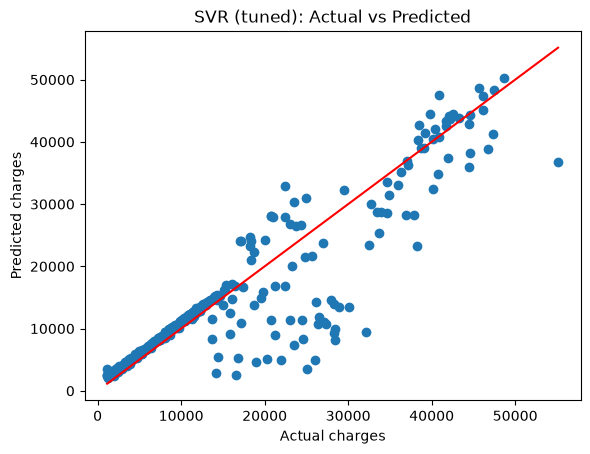

In [24]:
plt.scatter(y_test, y_test_pred_best)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r')
plt.title('SVR (tuned): Actual vs Predicted')
plt.xlabel('Actual charges')
plt.ylabel('Predicted charges')
plt.show()

## Evaluation Results

In [25]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'SVR (default)', 'SVR (tuned)'],
    'R-squared': [r2_lr, r2_svr, r2_best],
    'MSE': [mse_lr, mse_svr, mse_best],
    'RMSE': [rmse_lr, rmse_svr, rmse_best],
    'MAE': [mae_lr, mae_svr, mae_best]
})
comparison

,Model,R-squared,MSE,RMSE,MAE
0,Linear Regression,0.741560,3.615400e+07,6012.819780,4198.398028
1,SVR (default),0.824254,2.458565e+07,4958.391700,2696.734764
2,SVR (tuned),0.828575,2.398116e+07,4897.056353,2699.951528


## Analysis of Results

| Model | R-squared | MSE | MAE |
|---|---|---|---|
| Linear Regression | 0.742 | 3.62 × 10⁷ | 4,198 |
| SVR (default) | 0.824 | 2.46 × 10⁷ | 2,697 |
| SVR (tuned) | 0.829 | 2.40 × 10⁷ | 2,700 |

1. **Linear Regression** explains about 74% of the variation in medical charges. Its predictions are off by about 4,200 USD on average (MAE).
2. **SVR performs better** than Linear Regression on all metrics. Even with default parameters, R-squared rises to 0.824 and the MAE drops from about 4,200 to about 2,700.
3. **Hyperparameter tuning gave only a small improvement** (R-squared 0.824 → 0.829, MSE slightly lower, MAE about the same). The default SVR was already close to a good setting; the best parameters were the `rbf` kernel with `C = 3`, `gamma = 0.05` and `epsilon = 0.1`. The `linear` kernel was clearly the worst in tuning, which shows the relationship is not linear.
4. **Why SVR is better:** the charges do not increase in a straight line. The scatter plot shows that smokers with a high BMI have much higher charges than others, i.e. the effect of BMI depends on smoking. Linear Regression can only add up separate effects, while the `rbf` kernel can fit this curved pattern.
5. **Most important features:** from the Linear Regression coefficients and the heatmap, `smoker` has the largest effect on charges, followed by `age` and `bmi`. `sex` and `region` have very small effects.
6. **Weaknesses:** in the actual vs predicted plots, both models still make large errors for some people with high charges. The dataset is also small (1,338 rows). Possible improvements are adding a feature that combines smoker and BMI, or trying other models.